# Analyse du classeur `279493_Novapress850_H2_1-mm.xls`

Ce classeur regroupe les resultats d'un **essai mecanique sur un joint d'etancheite**
(joint *Novapress 850*, essai n 279493, realise le 16/07/2024).

Le fichier porte l'extension `.xls` mais il s'agit en realite d'un classeur **`.xlsx`**
moderne : il faut donc le lire avec le moteur `openpyxl`.

## Les 10 feuilles du classeur

| # | Feuille | Type | Role |
|---|---------|------|------|
| 1 | **Test** | Graphique | Test d'etancheite : Fuite vs Temps + Contrainte/Pression |
| 2 | **Test2** | Graphique | Comportement mecanique : Ecrasement vs Temps |
| 3 | **Sg vs E** | Graphique | Compression / reprise elastique (Contrainte vs Ecrasement) |
| 4 | **Sg vs Dg** | Graphique | Compression / reprise elastique (Contrainte vs Deflexion) |
| 5 | **Donnees** | Donnees | Mesures brutes (~7325 points : temps, contrainte, pression, fuite...) |
| 6 | **DonneesT** | Donnees | Synthese par palier/etape (STEP) |
| 7 | **DonneesT2** | Donnees | Tableau de synthese formate (bilingue FR/EN) |
| 8 | **Description** | Description | Fiche d'identite de l'essai (joint, dimensions, parametres) |
| 9 | **Legend** | Description | Libelles et titres utilises par les graphiques |
| 10 | **Feuil3** | Superflue | Brouillon redondant de `DonneesT` |

Les **4 premieres feuilles sont des feuilles-graphiques** (chartsheets) : elles ne
contiennent pas de cellules, seulement un graphique construit a partir de la feuille
**`Donnees`**.

> Objectif de ce notebook : **reconstruire le premier graphique (`Test`)** a partir
> des donnees brutes.

In [1]:
# Bibliotheques
import pandas as pd
import matplotlib.pyplot as plt

FICHIER = "279493_Novapress850_H2_1-mm.xls"

# Le fichier est un .xlsx deguise en .xls -> moteur openpyxl obligatoire
xl = pd.ExcelFile(FICHIER, engine="openpyxl")
print("Feuilles de donnees (worksheets) :")
for nom in xl.sheet_names:
    print("  -", nom)
print()
print("Note : les 4 feuilles-graphiques (Test, Test2, Sg vs E, Sg vs Dg)")
print("n'apparaissent pas ci-dessus car ce sont des 'chartsheets', pas des tableaux.")

Feuilles de donnees (worksheets) :
  - Données
  - DonnéesT
  - DonnéesT2
  - Description
  - Légend
  - Feuil3

Note : les 4 feuilles-graphiques (Test, Test2, Sg vs E, Sg vs Dg)
n'apparaissent pas ci-dessus car ce sont des 'chartsheets', pas des tableaux.


## La feuille `Description` : contexte de l'essai

Avant de tracer, on lit la fiche d'identite de l'essai pour savoir ce que l'on mesure.

In [2]:
desc = pd.read_excel(FICHIER, sheet_name="Description", header=None, engine="openpyxl")
# Colonne 0 = libelle, colonne 1 ou 2 = valeur
fiche = desc.iloc[:, [0, 1, 2]].dropna(how="all")
for _, ligne in fiche.iterrows():
    libelle = ligne.iloc[0]
    valeur = ligne.iloc[2] if pd.notna(ligne.iloc[2]) else ligne.iloc[1]
    if pd.notna(libelle) and pd.notna(valeur):
        print(f"{str(libelle):38s} : {valeur}")

Nom de l'essai                         : 279493_Novapress850_H2_1
Date                                   : 16/07/2024
Joint                                  : Novapress 850
Dimensions                             : 49.1 x 91.74 x 1.95 mm
Diamètres extérieur                    : 91.74
Dimensions Plateau                     : 43x88
Caractéristiques système               : Dimensions : Joint/Gasket : 49.1 x 91.74 x 1.95 mm
Type de joint                          : Novapress 850
Fabriquant du joint                    : Frenzelit
Référence du joint                     : 279493_Novapress850_H2_1
Date de l'essai                        : 16/07/2024
Diamètre intérieur du joint            : 49.1
Epaisseur du joint                     : 1.95
Diamètre intérieur du centreur         : 0
Diamètre extérieur du centreur         : 0
Epaisseur du centreur                  : 0
Référence du spectromètre              : 14
Sécurité écrasement                    : N
Paramètre sécurité écrasement          : 1000

## Le graphique `Test`

D'apres la feuille `Legend`, le premier graphique porte le titre
**\"Test d'Etancheite / Sealing Test\"** et il combine **3 courbes** tracees
en fonction du **temps** :

| Courbe | Grandeur | Colonne dans `Donnees` | Axe |
|--------|----------|------------------------|-----|
| Fuite / Leak (mg/(s.m)) | etancheite du joint | D | gauche (bleu) |
| Contrainte / Stress (MPa) | contrainte effective sur le joint | B | droite |
| Pression / Pressure (bar) | pression du fluide (helium) | C | droite |

C'est donc un graphique a **double axe Y** : la fuite (tres petite, en mg/(s.m))
sur l'axe de gauche, la contrainte et la pression (memes ordres de grandeur)
sur l'axe de droite.

On charge uniquement les 4 colonnes utiles de la feuille `Donnees`.

In [3]:
donnees = pd.read_excel(
    FICHIER,
    sheet_name="Données",   # nom exact de la feuille, avec l'accent
    engine="openpyxl",
    usecols=[0, 1, 2, 3],   # A=Temps, B=Contrainte, C=Pression, D=Fuite
)
# On renomme pour des noms courts et manipulables
donnees.columns = ["temps_s", "contrainte_MPa", "pression_bar", "fuite_mg_s_m"]

print("Dimensions :", donnees.shape)
donnees.head()

Dimensions : (7325, 4)


,temps_s,contrainte_MPa,pression_bar,fuite_mg_s_m
0,54.110271,0.338408,0.182359,4.595925e-07
1,54.210251,0.357448,0.181996,4.592784e-07
2,54.310534,0.370948,0.179501,4.597373e-07
3,54.411011,0.395490,0.182117,4.595592e-07
4,54.511138,0.432808,0.182670,4.595572e-07


In [4]:
# Apercu statistique rapide des grandeurs mesurees
donnees.describe()

,temps_s,contrainte_MPa,pression_bar,fuite_mg_s_m
count,7325.000000,7325.000000,7325.000000,7.325000e+03
mean,77107.725188,26.365485,33.621753,2.489822e-05
std,47467.554152,19.110260,14.724300,2.303073e-04
min,54.110271,0.098959,0.175663,4.503263e-07
25%,36093.189030,10.220947,39.996095,1.081968e-06
50%,80405.971098,20.126398,40.172740,1.679242e-06
75%,110556.987739,39.249062,40.367008,2.353309e-06
max,169561.091905,80.013380,41.250277,1.464314e-02


## Reconstruction du graphique `Test`

On reproduit le graphique d'origine :

- axe **X** : temps (s) ;
- axe **Y gauche** : fuite (mg/(s.m)), courbe **bleue** ;
- axe **Y droit** : contrainte effective (MPa) et pression (bar).

`twinx()` permet de superposer deux echelles Y differentes sur le meme graphique.

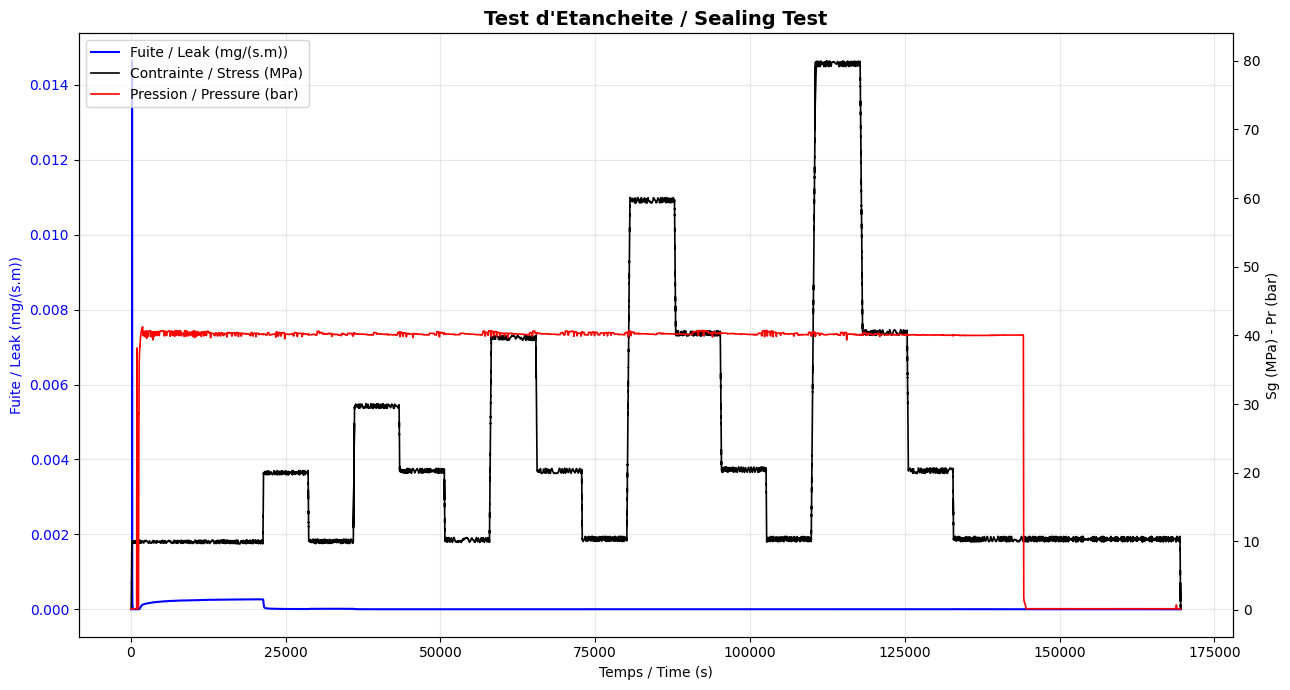

In [5]:
fig, ax_gauche = plt.subplots(figsize=(13, 7))

# --- Axe de gauche : la fuite (etancheite du joint) ---
courbe_fuite, = ax_gauche.plot(
    donnees["temps_s"], donnees["fuite_mg_s_m"],
    color="blue", linewidth=1.5, label="Fuite / Leak (mg/(s.m))",
)
ax_gauche.set_xlabel("Temps / Time (s)")
ax_gauche.set_ylabel("Fuite / Leak (mg/(s.m))", color="blue")
ax_gauche.tick_params(axis="y", labelcolor="blue")

# --- Axe de droite : contrainte et pression ---
ax_droite = ax_gauche.twinx()
courbe_contrainte, = ax_droite.plot(
    donnees["temps_s"], donnees["contrainte_MPa"],
    color="black", linewidth=1.2, label="Contrainte / Stress (MPa)",
)
courbe_pression, = ax_droite.plot(
    donnees["temps_s"], donnees["pression_bar"],
    color="red", linewidth=1.2, label="Pression / Pressure (bar)",
)
ax_droite.set_ylabel("Sg (MPa) - Pr (bar)")

# --- Titre et legende communs ---
plt.title("Test d'Etancheite / Sealing Test", fontsize=14, fontweight="bold")
courbes = [courbe_fuite, courbe_contrainte, courbe_pression]
ax_gauche.legend(courbes, [c.get_label() for c in courbes], loc="upper left")
ax_gauche.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## Lecture du graphique

- La **contrainte** (noir) est appliquee par **paliers croissants** : le joint est
  comprime de plus en plus fort au cours de l'essai.
- La **pression** d'helium (rouge) est maintenue a peu pres constante (~40 bar)
  pendant la mesure de fuite.
- La **fuite** (bleu) reste tres faible : c'est le critere d'**etancheite**.
  Tant qu'elle reste basse malgre la pression appliquee, le joint remplit son role.

Ce graphique `Test` permet donc de verifier que le joint *Novapress 850* reste
etanche pendant que la contrainte de serrage augmente.

### Pour aller plus loin
Le meme principe (lecture de `Donnees` + `twinx`) permettrait de reconstruire les
3 autres graphiques : `Test2` (ecrasement vs temps), `Sg vs E` et `Sg vs Dg`
(courbes de compression / reprise elastique).